In [1]:
from pathlib import Path
from CART.analyzers import SubnetPivotAnalyzer
from CART.base import Neo4jConnection
import pandas as pd

export_cypher = """
CALL apoc.export.csv.query(
  "MATCH (a:IP)-[r:CONNECTS]->(b:IP)\n   RETURN a.address AS src,\n          b.address AS dst,\n          r.timestamp AS ts,\n          r.is_attack AS is_attack",
  'thesis_results/connects_edges.csv',
  {batchSize: 50000, delimiter: ',', quotes: false}
 )
YIELD file, source, format, nodes, relationships, properties, time
RETURN file, source, format, nodes, relationships, properties, time;
"""

analyzer = SubnetPivotAnalyzer()
if not analyzer.connect():
    raise RuntimeError("Could not connect to Neo4j; ensure the database is running and credentials are correct.")

try:
    with analyzer.driver.session(database=analyzer.database) as session:
        check_query = (
            "SHOW PROCEDURES YIELD name "
            "WHERE name = 'apoc.export.csv.query' "
            "RETURN count(*) AS matches"
        )
        matches = session.run(check_query).single()["matches"]
        if matches == 0:
            raise RuntimeError(
                "apoc.export.csv.query is not registered. Restart the Neo4j container with APOC enabled."
            )
        import_dir = Path("thesis_results")
        import_dir.mkdir(parents=True, exist_ok=True)
        result = session.run(export_cypher).data()
        if not result:
            raise RuntimeError("APOC export returned no metadata; check Neo4j logs for details.")
        summary = result[0]
        print("CSV export complete:")
        for key, value in summary.items():
            print(f"  {key}: {value}")
finally:
    analyzer.close()

Neo4jConnection().ensure_export_permissions()

connects_path = Path("thesis_results/connects_edges.csv")
if not connects_path.exists():
    raise FileNotFoundError("connects_edges.csv was not written; run the export cell above first.")
connects_df = pd.read_csv(connects_path, usecols=["src","dst","ts","is_attack"])
connects_df["ts"] = connects_df["ts"].astype("int64")
print(f"Loaded {len(connects_df):,} edges from APOC export")

SubnetPivotAnalyzer initialized.
✓ Successfully connected to the Neo4j database.
CSV export complete:
  file: thesis_results/connects_edges.csv
  source: statement: cols(4)
  format: csv
  nodes: 0
  relationships: 0
  properties: 7594452
  time: 10665
✓ Neo4j connection closed.
Neo4jConnection initialized.
CSV export complete:
  file: thesis_results/connects_edges.csv
  source: statement: cols(4)
  format: csv
  nodes: 0
  relationships: 0
  properties: 7594452
  time: 10665
✓ Neo4j connection closed.
Neo4jConnection initialized.
Loaded 1,898,613 edges from APOC export
Loaded 1,898,613 edges from APOC export


In [2]:
import polars as pl

edges = pl.DataFrame(connects_df)
print(edges.head())
edges

shape: (5, 4)
┌──────────────┬─────────────┬────────────┬───────────┐
│ src          ┆ dst         ┆ ts         ┆ is_attack │
│ ---          ┆ ---         ┆ ---        ┆ ---       │
│ str          ┆ str         ┆ i64        ┆ i64       │
╞══════════════╪═════════════╪════════════╪═══════════╡
│ 143.88.15.10 ┆ 143.88.1.18 ┆ 1709187641 ┆ 1         │
│ 143.88.15.10 ┆ 143.88.1.18 ┆ 1730639410 ┆ 1         │
│ 143.88.15.10 ┆ 143.88.1.18 ┆ 1730743090 ┆ 1         │
│ 143.88.15.10 ┆ 143.88.1.18 ┆ 1730424538 ┆ 1         │
│ 143.88.15.10 ┆ 143.88.1.18 ┆ 1730555258 ┆ 1         │
└──────────────┴─────────────┴────────────┴───────────┘


src,dst,ts,is_attack
str,str,i64,i64
"""143.88.15.10""","""143.88.1.18""",1709187641,1
"""143.88.15.10""","""143.88.1.18""",1730639410,1
"""143.88.15.10""","""143.88.1.18""",1730743090,1
"""143.88.15.10""","""143.88.1.18""",1730424538,1
"""143.88.15.10""","""143.88.1.18""",1730555258,1
…,…,…,…
"""143.88.255.52""","""143.88.255.1""",1730466833,1
"""143.88.255.52""","""143.88.255.1""",1730526914,1
"""143.88.255.52""","""143.88.255.1""",1730440135,1


In [3]:
#from CART import Controller, Neo4jConnection, SubnetPivotAnalyzer

#connection = Neo4jConnection()
#connection.restart()
#connection.stop()
#connection.remove()


#connection.build_database()

In [4]:
import os
from pathlib import Path
import polars as pl
from typing import Literal, Optional
import pandas as pd
from CART.base import Neo4jConnection

def _prepare_ranked_edges(edges_lf: pl.LazyFrame, max_edges_per_node: Optional[int]) -> pl.LazyFrame:
    sorted_edges = edges_lf.sort("ts")
    ranked = sorted_edges.with_columns([
        pl.col("dst").cum_count().over("dst").alias("dst_rank"),
        pl.col("src").cum_count().over("src").alias("src_rank"),
    ])
    if max_edges_per_node is None:
        return ranked
    return ranked.filter(
        (pl.col("dst_rank") < max_edges_per_node) |
        (pl.col("src_rank") < max_edges_per_node)
    )

def _attach_subnets(df: pl.DataFrame, prefix: int) -> pl.DataFrame:
    if prefix != 24:
        raise ValueError("Only /24 subnets are supported right now.")
    pdf = df.to_pandas()
    for idx in range(1, 5):
        col = f"hop{idx}_ip"
        if col in pdf.columns:
            pdf[f"hop{idx}_subnet"] = pdf[col].str.rsplit('.', n=1).str[0] + '.0/24'
    return pl.from_pandas(pdf)

def build_multi_hop_chains(
    csv_path: str,
    *,
    mode: Literal["label_aware", "label_agnostic"] = "label_aware",
    max_edges_per_node: Optional[int] = 50,
    max_results: Optional[int] = None,
    streaming: bool = True,
    drop_duplicate_chains: bool = True,
    attach_subnets: bool = True,
    save_csv: Optional[str] = None,
    subnet_prefix: int = 24,
    return_total: bool = False,
    ) -> pl.DataFrame:
    """Construct A→B→C→D chains using Polars with optional down-sampling."""

    source_path = Path(csv_path)
    if not source_path.exists():
        raise FileNotFoundError(f"CSV file not found: {source_path}")
    if not os.access(source_path, os.R_OK):
        Neo4jConnection().ensure_export_permissions()
        if not os.access(source_path, os.R_OK):
            raise PermissionError(f"Unable to read {source_path}; adjust permissions and retry.")
    
    lf = pl.scan_csv(
        str(source_path),
        infer_schema_length=1000,
    ).select(["src", "dst", "ts", "is_attack"])
    
    if mode == "label_aware":
        lf = lf.filter(pl.col("is_attack") == 1)

    lf = lf.with_columns(pl.col("ts").cast(pl.Int64))

    ranked = _prepare_ranked_edges(lf, max_edges_per_node)

    hop1 = ranked.select([
        pl.col("src").alias("hop1_ip"),
        pl.col("dst").alias("hop2_ip"),
        pl.col("ts").alias("t1"),
    ])

    hop2 = ranked.select([
        pl.col("src").alias("hop2_ip"),
        pl.col("dst").alias("hop3_ip"),
        pl.col("ts").alias("t2"),
    ])

    hop3 = ranked.select([
        pl.col("src").alias("hop3_ip"),
        pl.col("dst").alias("hop4_ip"),
        pl.col("ts").alias("t3"),
    ])

    chains = (
        hop1.join(hop2, on="hop2_ip", how="inner")
            .filter(pl.col("t2") > pl.col("t1"))
            .join(hop3, on="hop3_ip", how="inner")
            .filter(pl.col("t3") > pl.col("t2"))
            .filter(pl.col("hop1_ip") != pl.col("hop3_ip"))
            .filter(pl.col("hop2_ip") != pl.col("hop4_ip"))
            .filter(pl.col("hop1_ip") != pl.col("hop4_ip"))
            .with_columns([
                ((pl.col("t2") - pl.col("t1")) / 3600.0).alias("hours_to_hop2"),
                ((pl.col("t3") - pl.col("t2")) / 3600.0).alias("hours_to_hop3"),
            ])
    )

    engine = "streaming" if streaming else None
    try:
        total_count = chains.select(pl.len().alias("count")).collect(engine=engine)[0, "count"]
    except pl.exceptions.ComputeError:
        total_count = chains.select(pl.len().alias("count")).collect(engine=None)[0, "count"]

    working_chains = chains
    if max_results is not None:
        working_chains = working_chains.limit(max_results)

    try:
        result = working_chains.collect(engine=engine)
    except pl.exceptions.ComputeError:
        result = working_chains.collect(engine=None)

    if attach_subnets:
        result = _attach_subnets(result, subnet_prefix)

    if save_csv:
        result.write_csv(save_csv)

    if return_total:
        return result, int(total_count)
    return result

def summarize_chains(df: pl.DataFrame, label: str, total: Optional[int] = None) -> None:
    if df.is_empty():
        print(f"{label}: no chains found")
        return
    pdf = df.to_pandas()
    total_count = int(total) if total is not None else df.height
    unique_ips = {
        f"hop{idx}_ip": pdf[f"hop{idx}_ip"].nunique() for idx in range(1, 5) if f"hop{idx}_ip" in pdf
    }
    unique_subnets = {
        f"hop{idx}_subnet": pdf[f"hop{idx}_subnet"].nunique() for idx in range(1, 5) if f"hop{idx}_subnet" in pdf
    }
    print(f"{label}: {total_count:,} chains")
    if unique_ips:
        print("  Unique IPs per hop:")
        for key, value in unique_ips.items():
            print(f"    {key}: {value:,}")
    if unique_subnets:
        print("  Unique subnets per hop:")
        for key, value in unique_subnets.items():
            print(f"    {key}: {value:,}")
    print("  Sample chains:")
    display(pdf.head(5))

label_aware_chains, label_aware_total = build_multi_hop_chains(
    "thesis_results/connects_edges.csv",
    mode="label_aware",
    max_edges_per_node=50,
    max_results=200000,
    streaming=True,
    save_csv="thesis_results/label_aware_chains_sample.csv",
    return_total=True,
)
summarize_chains(label_aware_chains, "Label-aware", total=label_aware_total)

label_agnostic_chains, label_agnostic_total = build_multi_hop_chains(
    "thesis_results/connects_edges.csv",
    mode="label_agnostic",
    max_edges_per_node=50,
    max_results=200000,
    streaming=True,
    save_csv="thesis_results/label_agnostic_chains_sample.csv",
    return_total=True,
)
summarize_chains(label_agnostic_chains, "Label-agnostic", total=label_agnostic_total)

Label-aware: 5,507,619 chains
  Unique IPs per hop:
    hop1_ip: 22
    hop2_ip: 10
    hop3_ip: 11
    hop4_ip: 38
  Unique subnets per hop:
    hop1_subnet: 11
    hop2_subnet: 10
    hop3_subnet: 10
    hop4_subnet: 13
  Sample chains:


,hop1_ip,hop2_ip,t1,hop3_ip,t2,hop4_ip,t3,hours_to_hop2,hours_to_hop3,hop1_subnet,hop2_subnet,hop3_subnet,hop4_subnet
0,143.88.0.34,143.88.255.1,1730393219,143.88.0.6,1730395794,143.88.0.5,1730406210,0.715278,2.893333,143.88.0.0/24,143.88.255.0/24,143.88.0.0/24,143.88.0.0/24
1,143.88.0.34,143.88.255.1,1730393219,143.88.0.6,1730395794,143.88.0.5,1730406210,0.715278,2.893333,143.88.0.0/24,143.88.255.0/24,143.88.0.0/24,143.88.0.0/24
2,143.88.0.34,143.88.255.1,1730393219,143.88.0.6,1730395794,143.88.0.5,1730406210,0.715278,2.893333,143.88.0.0/24,143.88.255.0/24,143.88.0.0/24,143.88.0.0/24
3,143.88.0.34,143.88.255.1,1730393219,143.88.0.6,1730395794,143.88.0.5,1730406211,0.715278,2.893611,143.88.0.0/24,143.88.255.0/24,143.88.0.0/24,143.88.0.0/24
4,143.88.0.34,143.88.255.1,1730393219,143.88.0.6,1730395794,143.88.0.5,1730406211,0.715278,2.893611,143.88.0.0/24,143.88.255.0/24,143.88.0.0/24,143.88.0.0/24


Label-agnostic: 5,507,619 chains
  Unique IPs per hop:
    hop1_ip: 21
    hop2_ip: 9
    hop3_ip: 13
    hop4_ip: 73
  Unique subnets per hop:
    hop1_subnet: 9
    hop2_subnet: 9
    hop3_subnet: 9
    hop4_subnet: 12
  Sample chains:


,hop1_ip,hop2_ip,t1,hop3_ip,t2,hop4_ip,t3,hours_to_hop2,hours_to_hop3,hop1_subnet,hop2_subnet,hop3_subnet,hop4_subnet
0,143.88.0.34,143.88.255.1,1730393219,143.88.0.6,1730395794,143.88.0.5,1730406210,0.715278,2.893333,143.88.0.0/24,143.88.255.0/24,143.88.0.0/24,143.88.0.0/24
1,143.88.0.34,143.88.255.1,1730393219,143.88.0.6,1730395794,143.88.0.5,1730406210,0.715278,2.893333,143.88.0.0/24,143.88.255.0/24,143.88.0.0/24,143.88.0.0/24
2,143.88.0.34,143.88.255.1,1730393219,143.88.0.6,1730395794,143.88.0.5,1730406210,0.715278,2.893333,143.88.0.0/24,143.88.255.0/24,143.88.0.0/24,143.88.0.0/24
3,143.88.0.34,143.88.255.1,1730393219,143.88.0.6,1730395794,143.88.0.5,1730406211,0.715278,2.893611,143.88.0.0/24,143.88.255.0/24,143.88.0.0/24,143.88.0.0/24
4,143.88.0.34,143.88.255.1,1730393219,143.88.0.6,1730395794,143.88.0.5,1730406211,0.715278,2.893611,143.88.0.0/24,143.88.255.0/24,143.88.0.0/24,143.88.0.0/24


In [6]:
try:
    from pyvis.network import Network
    from IPython.display import HTML, display
except ImportError as exc:
    raise ImportError(
        "Install pyvis to render the full attack graph: `pip install pyvis`."
    ) from exc

ROLE_COLORS = {
    "attacker": "#e41a1c",   # red
    "pivot": "#ffd60a",      # yellow
    "victim_only": "#7b1fa2", # purple
    "neutral": "#2ca02c",    # green
}

ROLE_LABELS = {
    "attacker": "Attacker",
    "pivot": "Pivot (victim → attacker)",
    "victim_only": "Victim only",
    "neutral": "Non-victim/attacker",
}

def _classify_roles(df: pd.DataFrame) -> tuple[set[str], set[str], set[str], set[str]]:
    attack_edges = df[df["is_attack"] == 1]
    attack_sources = set(attack_edges["src"])
    attack_targets = set(attack_edges["dst"])
    pivot_nodes = attack_sources & attack_targets
    attacker_only = attack_sources - pivot_nodes
    victim_only = attack_targets - attack_sources
    all_nodes = set(df["src"]).union(set(df["dst"]))
    neutral_nodes = all_nodes - attack_sources - attack_targets
    return attacker_only, pivot_nodes, victim_only, neutral_nodes

def visualize_full_attack_graph(
    df: pd.DataFrame,
    *,
    include_neutral: bool = True,
    max_nodes: Optional[int] = 8000,
    max_edges: Optional[int] = 25000,
    output_path: str = "thesis_results/attack_graph.html",
) -> str:
    """Render an interactive PyVis graph covering the attack flow."""
    attacker_only, pivot_nodes, victim_only, neutral_nodes = _classify_roles(df)

    node_subset = set(attacker_only | pivot_nodes | victim_only)
    if max_nodes is not None and len(node_subset) > max_nodes:
        print(
            f"Truncating attack-related nodes to {max_nodes} of {len(node_subset)}. "
            "Increase `max_nodes` or set to None for full coverage."
        )
        node_subset = set(sorted(node_subset)[:max_nodes])

    if include_neutral:
        if max_nodes is None:
            node_subset |= neutral_nodes
        else:
            remaining = max_nodes - len(node_subset)
            if remaining > 0:
                neutral_sample = sorted(neutral_nodes)[:remaining]
                node_subset |= set(neutral_sample)

    edges_df = df[df["src"].isin(node_subset) & df["dst"].isin(node_subset)]
    if max_edges is not None and len(edges_df) > max_edges:
        print(
            f"Truncating edges to first {max_edges} of {len(edges_df)} rows. "
            "Increase `max_edges` or set to None for full coverage."
        )
        edges_df = edges_df.head(max_edges)

    net = Network(height="900px", width="100%", directed=True, notebook=True, bgcolor="#0f172a", font_color="#f8fafc")
    net.force_atlas_2based(gravity=-35, spring_length=150, spring_strength=0.08)

    def role_for(node: str) -> str:
        if node in pivot_nodes:
            return "pivot"
        if node in attacker_only:
            return "attacker"
        if node in victim_only:
            return "victim_only"
        return "neutral"

    for node in node_subset:
        role = role_for(node)
        color = ROLE_COLORS[role]
        title = f"{node}<br/>Role: {ROLE_LABELS[role]}"
        net.add_node(node, label=node, color=color, title=title)

    for _, row in edges_df.iterrows():
        edge_color = "#ff595e" if row["is_attack"] == 1 else "#94a3b8"
        width = 3 if row["is_attack"] == 1 else 1
        net.add_edge(row["src"], row["dst"], color=edge_color, width=width, title=f"is_attack={row['is_attack']}")

    net.write_html(output_path, notebook=True)
    display(HTML(filename=output_path))
    print(f"Interactive attack graph saved to {output_path}")
    return output_path

attack_graph_path = visualize_full_attack_graph(
    connects_df,
    include_neutral=True,
    max_nodes=8000,
    max_edges=25000,
)

Truncating edges to first 25000 of 1898613 rows. Increase `max_edges` or set to None for full coverage.


Interactive attack graph saved to thesis_results/attack_graph.html


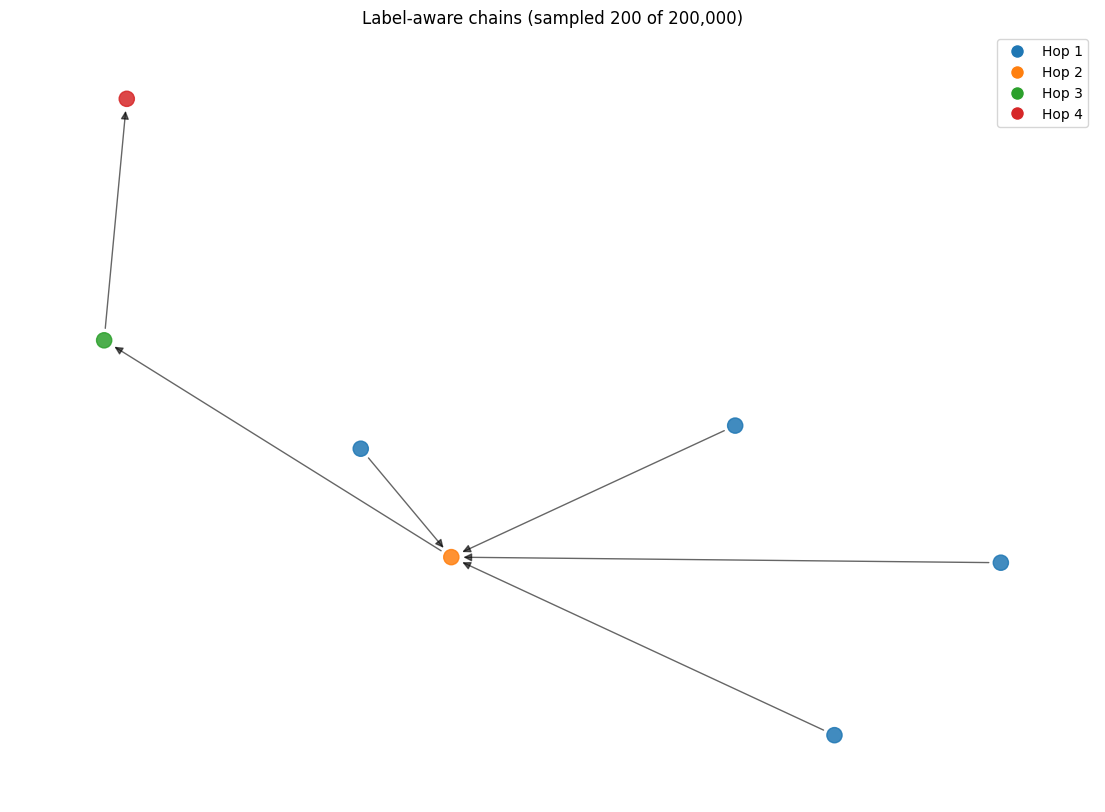

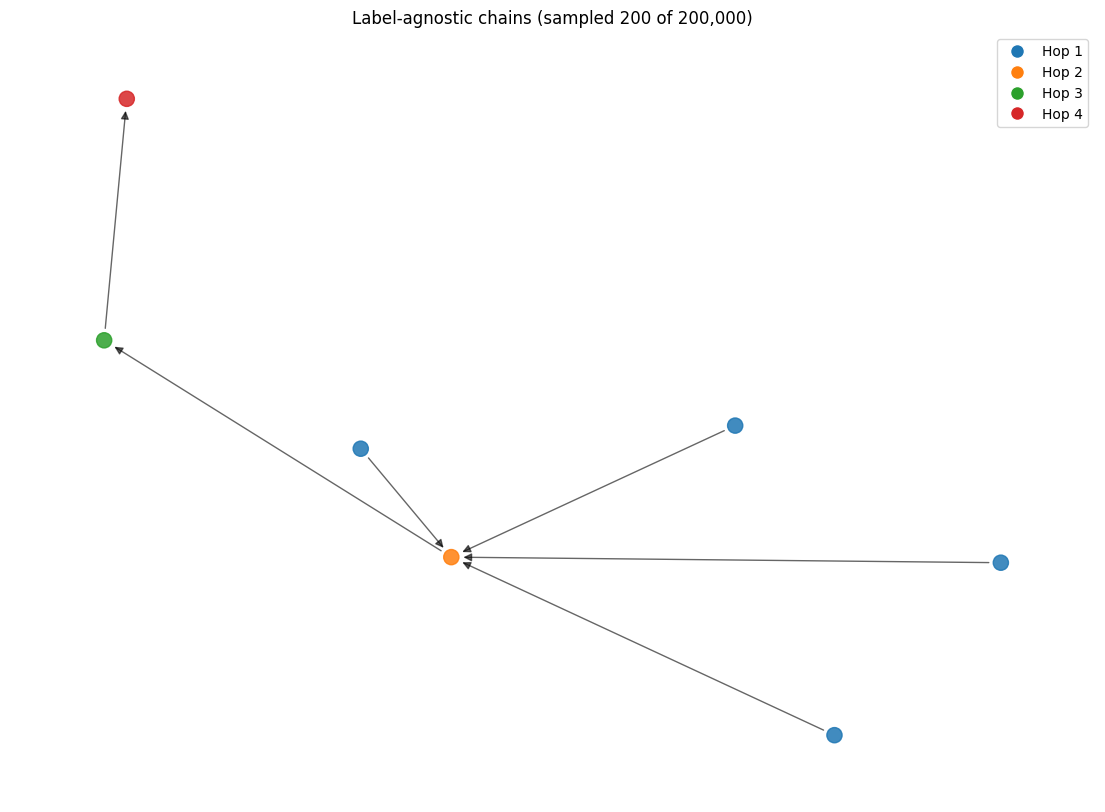

In [5]:
try:
    import networkx as nx
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise ImportError(
        "Install networkx and matplotlib to visualize chains: `pip install networkx matplotlib`."
    ) from exc

_HOP_COLOR_MAP = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c", 4: "#d62728"}

def _add_chain_to_graph(graph: nx.DiGraph, chain: dict) -> None:
    nodes = [chain.get(f"hop{idx}_ip") for idx in range(1, 5)]
    nodes = [node for node in nodes if node]
    for hop_index, node in enumerate(nodes, start=1):
        if node not in graph:
            graph.add_node(node, hop=hop_index)
    for idx in range(len(nodes) - 1):
        graph.add_edge(nodes[idx], nodes[idx + 1])

def visualize_chain_network(
    df: pl.DataFrame,
    label: str,
    limit: int = 250,
    *,
    layout_seed: int = 42,
    figsize: tuple[int, int] = (14, 10),
    show_node_labels: bool = False,
    ) -> None:
    """Render a hop-to-hop graph from the provided chain sample."""
    if df.is_empty():
        print(f"{label}: no chains available for visualization")
        return

    sample_pdf = df.head(limit).to_pandas()
    graph = nx.DiGraph()
    for _, row in sample_pdf.iterrows():
        _add_chain_to_graph(graph, row.to_dict())

    if graph.number_of_edges() == 0:
        print(f"{label}: sample contained no edges after filtering")
        return

    hop_colors = [
        _HOP_COLOR_MAP.get(graph.nodes[node].get("hop", 0), "#7f7f7f") for node in graph.nodes
    ]
    pos = nx.spring_layout(graph, seed=layout_seed, k=0.6)
    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(graph, pos, node_color=hop_colors, node_size=120, alpha=0.85)
    nx.draw_networkx_edges(graph, pos, arrowstyle="-|>", arrowsize=12, alpha=0.6)
    if show_node_labels:
        nx.draw_networkx_labels(graph, pos, font_size=8, font_color="black")
    plt.title(f"{label} chains (sampled {min(limit, len(sample_pdf))} of {df.height:,})")
    legend_handles = [
        plt.Line2D([0], [0], marker="o", color="w", label=f"Hop {idx}",
                   markerfacecolor=color, markersize=10)
        for idx, color in _HOP_COLOR_MAP.items()
    ]
    plt.legend(handles=legend_handles, loc="upper right")
    plt.axis("off")
    plt.show()

visualize_chain_network(label_aware_chains, "Label-aware", limit=200, show_node_labels=False)
visualize_chain_network(label_agnostic_chains, "Label-agnostic", limit=200, show_node_labels=False)